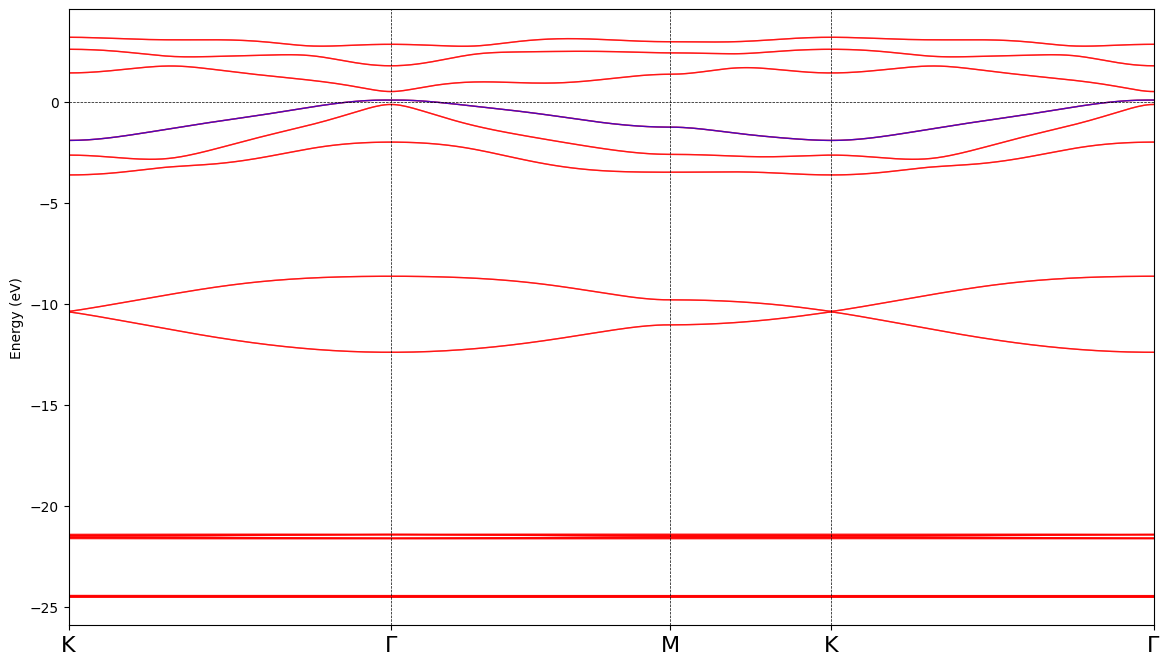

In [9]:
import matplotlib.pyplot as plt
from matplotlib import rcParamsDefault
import numpy as np

data = np.loadtxt('wannier90_band.dat')

k = np.unique(data[:, 0])
bands = np.reshape(data[:, 1], (-1, len(k)))

fermi_level = -1.1536428057

high_symmetry_points = [0, 0.9538331211, 1.7798850910, 2.2568016570, 3.2106347780]  
high_symmetry_labels = [ 'K', r'$\Gamma$','M', 'K', r'$\Gamma$']

plt.figure(figsize=(14, 8))

for band in range(len(bands)):
    plt.plot(k, bands[band, :]-fermi_level, linewidth=1, alpha=0.7, color='red')
plt.xlim(min(k), max(k))

plt.plot(k, bands[29, :]-fermi_level, linewidth=1, alpha=0.7, color='blue')

plt.axhline(0, color='black', linestyle='--', lw=0.5)
for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)
plt.ylabel("Energy (eV)")
#plt.ylim(-5,5)
plt.show()


+----------------------------------------------------------------------+
| ===================                                                  |
| SURFACE CALCULATION                                                  |
| ===================                                                  |
| starting at 2025-11-16 15:24:55,192                                  |
| running Z2Pack version 2.2.1                                         |
|                                                                      |
| gap_tol:            0.3                                              |
| init_result:        None                                             |
| iterator:           range(30, 101, 5)                                |
| load:               False                                            |
| load_quiet:         True                                             |
| min_neighbour_dist: 0.01                                             |
| move_tol:           0.3                         

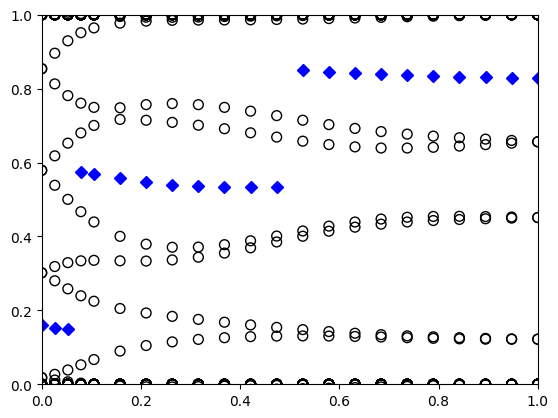

In [11]:
import z2pack
import tbmodels
import matplotlib.pyplot as plt

model = tbmodels.Model.from_wannier_files(hr_file='wannier90_hr.dat',occ=30)
system = z2pack.tb.System(model)
result = z2pack.surface.run(
    system=system,
    surface=lambda t1, t2: [t1/2,t2,0.0],num_lines=20,iterator=range(30, 101, 5)
)
   # Prints the Chern number

z2pack.plot.wcc(result)
print(z2pack.invariant.z2(result))
plt.show() 